# J03 — Courbe de rétention, hystérésis et fonctions de pédotransfert

**Physique et hydrodynamique des sols** — S. J. Gumiere

*Atelier du Jour 3 : ajustement VG/BC, points remarquables et réserve utile, pédotransfert, hystérésis*

> Version **instructeur** : code complet et résultats.

## Mise en place

Les données sont dans le dossier `data/`. Unités du cours : $h$ en cm (négatif en non saturé), $\theta$ en m³/m³, $K_s$ en cm/j.
Les sols de référence sont ceux de Carsel & Parrish (1988) : la cellule suivante importe les bibliothèques et construit
le tableau `cp` de leurs paramètres de van Genuchten ($\theta_r$, $\theta_s$, $\alpha$ en cm$^{-1}$, $n$, $K_s$ en cm/j) par classe texturale.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import erfc

# Carsel & Parrish (1988) : paramètres de van Genuchten moyens par classe texturale USDA
cp = pd.DataFrame({
    "classe": ["sable", "loam sableux", "loam", "loam limoneux", "loam argileux", "argile"],
    "theta_r": [0.045, 0.065, 0.078, 0.067, 0.095, 0.068],
    "theta_s": [0.43, 0.41, 0.43, 0.45, 0.41, 0.38],
    "alpha": [0.145, 0.075, 0.036, 0.020, 0.019, 0.008],      # 1/cm
    "n": [2.68, 1.89, 1.56, 1.41, 1.31, 1.09],
    "Ks": [712.8, 106.1, 24.96, 10.8, 6.24, 4.8],             # cm/j
})
cp = cp.set_index("classe")
print(cp)

               theta_r  theta_s  alpha     n      Ks
classe                                              
sable            0.045     0.43  0.145  2.68  712.80
loam sableux     0.065     0.41  0.075  1.89  106.10
loam             0.078     0.43  0.036  1.56   24.96
loam limoneux    0.067     0.45  0.020  1.41   10.80
loam argileux    0.095     0.41  0.019  1.31    6.24
argile           0.068     0.38  0.008  1.09    4.80


## Exercice 1 — Ajustement des modèles de van Genuchten et de Brooks–Corey  *(≈ 20 min)*

`data/J03_retention_mesures.csv` : couples $(h, \theta)$ mesurés en drainage (9 points, bruit expérimental) sur un sable, un loam
et une argile. Modèles :

* van Genuchten (1980) : $\theta(h) = \theta_r + (\theta_s - \theta_r)\,[1 + (\alpha|h|)^n]^{-m}$ avec $m = 1 - 1/n$ ;
* Brooks–Corey (1964) : $\theta = \theta_s$ si $|h| \le h_b$, sinon $\theta = \theta_r + (\theta_s - \theta_r)\,(h_b/|h|)^\lambda$.

1. Pour chaque sol, ajuster le modèle de van Genuchten ($\theta_r$, $\theta_s$, $\alpha$, $n$) avec `curve_fit`, en imposant des
   bornes physiques ($0 \le \theta_r \le 0{,}25$, $0{,}3 \le \theta_s \le 0{,}6$, $10^{-4} \le \alpha \le 1$, $1{,}05 \le n \le 8$)
   et une initialisation raisonnable ; calculer le RMSE et le $R^2$ de chaque ajustement.
2. Faire de même avec le modèle de Brooks–Corey ($\theta_r$, $\theta_s$, $h_b$, $\lambda$ ; bornes $1 \le h_b \le 500$ cm,
   $0{,}05 \le \lambda \le 3$).
3. Comparer les paramètres VG ajustés à ceux de Carsel & Parrish (tableau `cp`) et tracer, pour les trois sols, les points
   mesurés et les deux modèles ($|h|$ en échelle log).
4. Tracer la capacité capillaire du modèle VG (échelle log–log) :
   $C(h) = d\theta/dh = (\theta_s-\theta_r)\,\alpha\,n\,m\,(\alpha|h|)^{n-1}\,[1+(\alpha|h|)^n]^{-m-1}$.
5. Extraire de la matrice de covariance les écarts-types des paramètres VG et la corrélation entre $\alpha$ et $n$.

**Lecture des données**

In [2]:
mes = pd.read_csv("data/J03_retention_mesures.csv")
print(mes)

       sol     h_cm   theta
0    sable     -1.0  0.4225
1    sable     -3.0  0.4026
2    sable    -10.0  0.2073
3    sable    -30.0  0.0791
4    sable   -100.0  0.0439
5    sable   -330.0  0.0586
6    sable  -1000.0  0.0367
7    sable  -5000.0  0.0369
8    sable -15000.0  0.0345
9     loam     -1.0  0.4325
10    loam     -3.0  0.4168
11    loam    -10.0  0.4159
12    loam    -30.0  0.3401
13    loam   -100.0  0.2481
14    loam   -330.0  0.1808
15    loam  -1000.0  0.1190
16    loam  -5000.0  0.0723
17    loam -15000.0  0.0935
18  argile     -1.0  0.3850
19  argile     -3.0  0.3791
20  argile    -10.0  0.3785
21  argile    -30.0  0.3845
22  argile   -100.0  0.3524
23  argile   -330.0  0.3467
24  argile  -1000.0  0.3393
25  argile  -5000.0  0.2870
26  argile -15000.0  0.2702


**1. Modèle de van Genuchten : ajustement, RMSE et R²**

In [3]:
# teneur en eau de van Genuchten (1980) ; h en cm, alpha en 1/cm, m = 1 - 1/n
def vg_theta(h, thr, ths, alpha, n):
    m = 1 - 1 / n
    return thr + (ths - thr) * (1 + (alpha * np.abs(h)) ** n) ** (-m)

p0_vg = [0.05, 0.45, 0.02, 1.5]                          # valeurs de départ : theta_r, theta_s, alpha, n
bornes_vg = ([0, 0.3, 1e-4, 1.05], [0.25, 0.6, 1, 8])    # (minimums, maximums)

resultats = []
for sol in ["sable", "loam", "argile"]:
    g = mes[mes["sol"] == sol]
    h = g["h_cm"].to_numpy()
    theta = g["theta"].to_numpy()
    popt, pcov = curve_fit(vg_theta, h, theta, p0=p0_vg, bounds=bornes_vg)
    # qualité de l'ajustement : erreur quadratique moyenne et part de variance expliquée
    erreur = theta - vg_theta(h, popt[0], popt[1], popt[2], popt[3])
    rmse = np.sqrt(np.mean(erreur**2))
    r2 = 1 - np.sum(erreur**2) / np.sum((theta - theta.mean())**2)
    resultats.append([sol, popt[0], popt[1], popt[2], popt[3], rmse, r2])

par_vg = pd.DataFrame(resultats, columns=["sol", "theta_r", "theta_s", "alpha", "n", "RMSE", "R2"])
par_vg = par_vg.set_index("sol")
print(par_vg.round(4))

        theta_r  theta_s   alpha       n    RMSE      R2
sol                                                     
sable    0.0412   0.4269  0.1509  2.5792  0.0066  0.9981
loam     0.0611   0.4301  0.0372  1.4848  0.0103  0.9945
argile   0.0000   0.3816  0.0084  1.0709  0.0074  0.9658


**2. Modèle de Brooks–Corey : ajustement, RMSE et R²**

In [4]:
# teneur en eau de Brooks & Corey (1964) ; hb = pression d'entrée d'air (cm, > 0), lam = indice de distribution des pores
# la saturation effective vaut (hb/|h|)^lam, plafonnée à 1 tant que |h| <= hb
def bc_theta(h, thr, ths, hb, lam):
    Se = np.minimum(1.0, (hb / np.abs(h)) ** lam)
    return thr + (ths - thr) * Se

p0_bc = [0.05, 0.45, 20, 0.5]                            # valeurs de départ : theta_r, theta_s, hb, lambda
bornes_bc = ([0, 0.3, 1, 0.05], [0.25, 0.6, 500, 3])     # (minimums, maximums)

resultats = []
for sol in ["sable", "loam", "argile"]:
    g = mes[mes["sol"] == sol]
    h = g["h_cm"].to_numpy()
    theta = g["theta"].to_numpy()
    popt, pcov = curve_fit(bc_theta, h, theta, p0=p0_bc, bounds=bornes_bc)
    erreur = theta - bc_theta(h, popt[0], popt[1], popt[2], popt[3])
    rmse = np.sqrt(np.mean(erreur**2))
    r2 = 1 - np.sum(erreur**2) / np.sum((theta - theta.mean())**2)
    resultats.append([sol, popt[0], popt[1], popt[2], popt[3], rmse, r2])

par_bc = pd.DataFrame(resultats, columns=["sol", "theta_r", "theta_s", "hb", "lambda", "RMSE", "R2"])
par_bc = par_bc.set_index("sol")
print(par_bc.round(4))

        theta_r  theta_s       hb  lambda    RMSE      R2
sol                                                      
sable    0.0400   0.4125   5.4408  1.3167  0.0079  0.9973
loam     0.0396   0.4217  15.6182  0.3465  0.0113  0.9934
argile   0.0000   0.3818  42.3878  0.0551  0.0084  0.9564


**3. Comparaison avec Carsel & Parrish et tracé des courbes**

Paramètres VG ajustés :
        theta_r  theta_s   alpha       n
sol                                     
sable    0.0412   0.4269  0.1509  2.5792
loam     0.0611   0.4301  0.0372  1.4848
argile   0.0000   0.3816  0.0084  1.0709

Paramètres de Carsel & Parrish (référence) :
        theta_r  theta_s  alpha     n
classe                               
sable     0.045     0.43  0.145  2.68
loam      0.078     0.43  0.036  1.56
argile    0.068     0.38  0.008  1.09


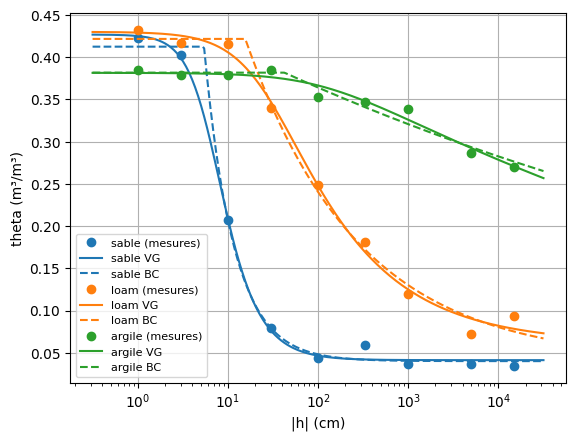

In [5]:
print("Paramètres VG ajustés :")
print(par_vg[["theta_r", "theta_s", "alpha", "n"]].round(4))
print()
print("Paramètres de Carsel & Parrish (référence) :")
print(cp.loc[["sable", "loam", "argile"], ["theta_r", "theta_s", "alpha", "n"]])

hh = -np.logspace(-0.5, 4.5, 300)     # h de -0,3 à -30 000 cm pour tracer les courbes
sols = ["sable", "loam", "argile"]
couleurs = ["C0", "C1", "C2"]

plt.figure()
for i in range(3):
    sol = sols[i]
    g = mes[mes["sol"] == sol]
    theta_vg = vg_theta(hh, par_vg.loc[sol, "theta_r"], par_vg.loc[sol, "theta_s"], par_vg.loc[sol, "alpha"], par_vg.loc[sol, "n"])
    theta_bc = bc_theta(hh, par_bc.loc[sol, "theta_r"], par_bc.loc[sol, "theta_s"], par_bc.loc[sol, "hb"], par_bc.loc[sol, "lambda"])
    plt.semilogx(-g["h_cm"], g["theta"], "o", color=couleurs[i], label=sol + " (mesures)")
    plt.semilogx(-hh, theta_vg, "-", color=couleurs[i], label=sol + " VG")
    plt.semilogx(-hh, theta_bc, "--", color=couleurs[i], label=sol + " BC")
plt.xlabel("|h| (cm)")
plt.ylabel("theta (m³/m³)")
plt.legend(fontsize=8)
plt.grid(True)
plt.show()

**4. Capacité capillaire C(h) du modèle VG**

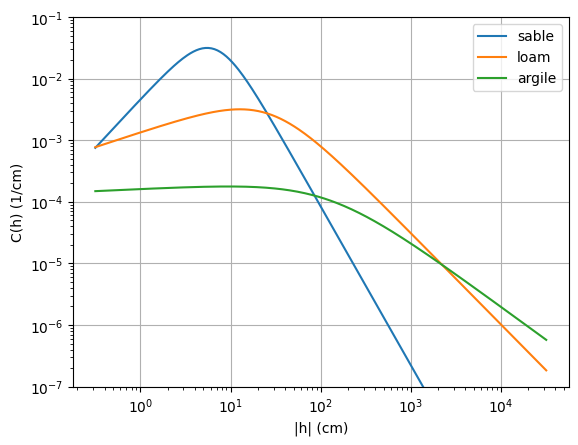

In [6]:
# capacité capillaire C(h) = dtheta/dh (1/cm) du modèle de van Genuchten
def vg_C(h, thr, ths, alpha, n):
    m = 1 - 1 / n
    ah = alpha * np.abs(h)
    return (ths - thr) * alpha * n * m * ah ** (n - 1) * (1 + ah ** n) ** (-m - 1)

plt.figure()
for sol in ["sable", "loam", "argile"]:
    C = vg_C(hh, par_vg.loc[sol, "theta_r"], par_vg.loc[sol, "theta_s"], par_vg.loc[sol, "alpha"], par_vg.loc[sol, "n"])
    plt.loglog(-hh, C, label=sol)
plt.ylim(1e-7, 1e-1)
plt.xlabel("|h| (cm)")
plt.ylabel("C(h) (1/cm)")
plt.legend()
plt.grid(True)
plt.show()

**5. Incertitudes des paramètres VG et corrélation alpha–n**

In [7]:
for sol in ["sable", "loam", "argile"]:
    g = mes[mes["sol"] == sol]
    h = g["h_cm"].to_numpy()
    theta = g["theta"].to_numpy()
    popt, pcov = curve_fit(vg_theta, h, theta, p0=p0_vg, bounds=bornes_vg)
    # écart type de chaque paramètre = racine carrée de la diagonale de la matrice de covariance
    ecart_type = np.sqrt(np.diag(pcov))
    # coefficient de corrélation entre alpha (indice 2) et n (indice 3)
    corr_alpha_n = pcov[2, 3] / (ecart_type[2] * ecart_type[3])
    print(f"{sol:7s} : alpha = {popt[2]:.4f} ± {ecart_type[2]:.4f}, n = {popt[3]:.3f} ± {ecart_type[3]:.3f}, corr(alpha, n) = {corr_alpha_n:+.2f}")

sable   : alpha = 0.1509 ± 0.0147, n = 2.579 ± 0.226, corr(alpha, n) = -0.85
loam    : alpha = 0.0372 ± 0.0107, n = 1.485 ± 0.112, corr(alpha, n) = -0.82
argile  : alpha = 0.0084 ± 0.0118, n = 1.071 ± 0.315, corr(alpha, n) = -0.87


**Commentaire (instructeur).** Les deux modèles reproduisent les données à ~0,005–0,01 près (l'ordre du bruit) ; VG est légèrement meilleur pour le loam et
l'argile, BC pour le sable (chute brutale). Les paramètres VG retrouvés sont proches de Carsel & Parrish, sauf $\theta_r$ et $n$
de l'argile, mal contraints (courbe presque plate : $n \to 1$, forte incertitude). La corrélation négative entre $\alpha$ et $n$
(−0,8 à −0,9) montre que ces deux paramètres se compensent : c'est un problème d'identifiabilité classique (Jour 10).

## Exercice 2 — Points remarquables, réserve utile et réserve facilement utilisable  *(≈ 10 min)*

Avec les paramètres VG ajustés à l'exercice 1 (tableau `par_vg`) :

1. Calculer $\theta$ à $-100$, $-330$ et $-15\,000$ cm pour chaque sol ; en déduire la réserve utile par mètre de sol,
   $\mathrm{RU} = (\theta_{cc} - \theta_{pf}) \times 1000$ mm, selon les deux conventions de capacité au champ ($-100$ et $-330$ cm).
2. Pour un enracinement $Z = 60$ cm et $p = 0{,}5$, calculer la RFU (mm) et le nombre de jours d'autonomie sans pluie pour
   $\mathrm{ET}_c = 5$ mm/j (convention $-330$ cm pour le loam et l'argile, $-100$ cm pour le sable).
3. Représenter en barres $\theta_s$, $\theta_{-100}$, $\theta_{-330}$ et $\theta_{-15000}$ pour les trois sols.

**1. Points remarquables et réserve utile**

In [8]:
lignes = []
for sol in ["sable", "loam", "argile"]:
    thr = par_vg.loc[sol, "theta_r"]
    ths = par_vg.loc[sol, "theta_s"]
    alpha = par_vg.loc[sol, "alpha"]
    n = par_vg.loc[sol, "n"]
    # teneurs en eau aux deux conventions de capacité au champ et au point de flétrissement
    theta_100 = vg_theta(-100, thr, ths, alpha, n)
    theta_330 = vg_theta(-330, thr, ths, alpha, n)
    theta_pf = vg_theta(-15000, thr, ths, alpha, n)
    # réserve utile par mètre de sol (mm)
    RU_100 = (theta_100 - theta_pf) * 1000
    RU_330 = (theta_330 - theta_pf) * 1000
    lignes.append([sol, ths, theta_100, theta_330, theta_pf, RU_100, RU_330])

pts = pd.DataFrame(lignes, columns=["sol", "theta_s", "theta_100", "theta_330", "theta_15000", "RU100_mm_m", "RU330_mm_m"])
pts = pts.set_index("sol")
print(pts.round(3))

        theta_s  theta_100  theta_330  theta_15000  RU100_mm_m  RU330_mm_m
sol                                                                       
sable     0.427      0.047      0.042        0.041       5.303       0.804
loam      0.430      0.248      0.170        0.078     169.664      91.347
argile    0.382      0.367      0.348        0.271      95.893      77.509


**2. Réserve facilement utilisable et autonomie**

In [9]:
Z = 0.6      # profondeur d'enracinement (m)
p = 0.5      # fraction facilement utilisable de la RU
ETc = 5.0    # évapotranspiration de la culture (mm/j)

for sol in ["sable", "loam", "argile"]:
    # convention de capacité au champ : -100 cm pour le sable, -330 cm pour le loam et l'argile
    if sol == "sable":
        RU = pts.loc[sol, "RU100_mm_m"]
    else:
        RU = pts.loc[sol, "RU330_mm_m"]
    RFU = p * RU * Z
    autonomie = RFU / ETc
    print(f"{sol:7s} : RU = {RU:6.1f} mm/m, RFU sur 60 cm = {RFU:5.1f} mm, autonomie = {autonomie:.1f} j")

sable   : RU =    5.3 mm/m, RFU sur 60 cm =   1.6 mm, autonomie = 0.3 j
loam    : RU =   91.3 mm/m, RFU sur 60 cm =  27.4 mm, autonomie = 5.5 j
argile  : RU =   77.5 mm/m, RFU sur 60 cm =  23.3 mm, autonomie = 4.7 j


**3. Diagramme en barres**

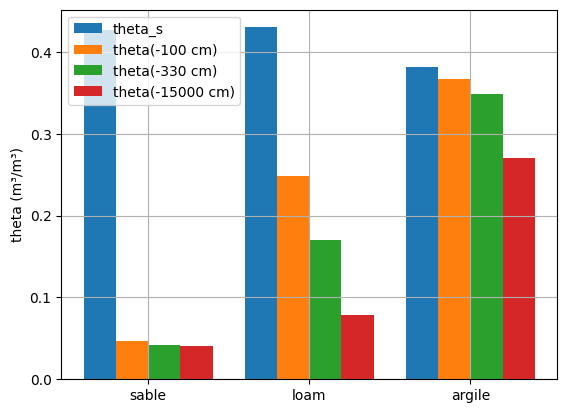

In [10]:
x = np.arange(3)      # une position par sol
largeur = 0.2

plt.figure()
plt.bar(x - 1.5 * largeur, pts["theta_s"], largeur, label="theta_s")
plt.bar(x - 0.5 * largeur, pts["theta_100"], largeur, label="theta(-100 cm)")
plt.bar(x + 0.5 * largeur, pts["theta_330"], largeur, label="theta(-330 cm)")
plt.bar(x + 1.5 * largeur, pts["theta_15000"], largeur, label="theta(-15000 cm)")
plt.xticks(x, ["sable", "loam", "argile"])
plt.ylabel("theta (m³/m³)")
plt.legend()
plt.grid(True)
plt.show()

**Commentaire (instructeur).** Le sable de Carsel & Parrish ne retient presque rien au-delà de −100 cm : RU de quelques mm/m, autonomie inférieure à un jour
(irréaliste pour un sable fin réel, plutôt 50–70 mm/m). Le loam donne ≈ 90 mm/m (convention −330) ou ≈ 170 mm/m (convention −100)
avec les paramètres ajustés, contre 77 et 154 mm/m avec ceux de Carsel & Parrish (diapositives) : le choix de la convention pèse
autant que la précision de l'ajustement. L'argile a une RU comparable au loam malgré une forte
$\theta_{cc}$, parce que $\theta_{pf}$ est élevée (eau retenue dans les pores les plus fins, inaccessible).

## Exercice 3 — Fonctions de pédotransfert : Saxton & Rawls vs Carsel & Parrish vs Rosetta  *(≈ 20 min)*

`data/J03_textures.csv` donne six sols A–F (sable, limon, argile, matière organique, $\rho_b$, classe USDA) et
`data/J03_rosetta_H3.csv` leurs paramètres VG prédits par Rosetta (niveau H3).

1. Calculer, pour les six sols, les prédictions de Saxton & Rawls (2006), avec S = sable et C = argile en fractions 0–1 et OM en % masse :

   $\theta_{1500}^t = -0{,}024S + 0{,}487C + 0{,}006\,OM + 0{,}005\,S\,OM - 0{,}013\,C\,OM + 0{,}068\,SC + 0{,}031$ ;
   $\theta_{1500} = \theta_{1500}^t + (0{,}14\,\theta_{1500}^t - 0{,}02)$

   $\theta_{33}^t = -0{,}251S + 0{,}195C + 0{,}011\,OM + 0{,}006\,S\,OM - 0{,}027\,C\,OM + 0{,}452\,SC + 0{,}299$ ;
   $\theta_{33} = \theta_{33}^t + (1{,}283\,(\theta_{33}^t)^2 - 0{,}374\,\theta_{33}^t - 0{,}015)$

   $\theta_{S-33}^t = 0{,}278S + 0{,}034C + 0{,}022\,OM - 0{,}018\,S\,OM - 0{,}027\,C\,OM - 0{,}584\,SC + 0{,}078$ ;
   $\theta_{S-33} = \theta_{S-33}^t + (0{,}636\,\theta_{S-33}^t - 0{,}107)$

   $\theta_s = \theta_{33} + \theta_{S-33} - 0{,}097S + 0{,}043$ ; $\lambda = (\ln\theta_{33} - \ln\theta_{1500})/(\ln 1500 - \ln 33)$ ;
   $K_s\,[\mathrm{mm/h}] = 1930\,(\theta_s - \theta_{33})^{3-\lambda}$ ;

   pression d'entrée d'air (kPa) : $\psi_e^t = -21{,}67S - 27{,}93C - 81{,}97\,\theta_{S-33} + 71{,}12\,S\,\theta_{S-33} + 8{,}29\,C\,\theta_{S-33} + 14{,}05\,SC + 27{,}16$,
   $\psi_e = \psi_e^t + (0{,}02\,(\psi_e^t)^2 - 0{,}113\,\psi_e^t - 0{,}70)$.
2. Comparer, pour chaque sol, $\theta(-33$ kPa$)$, $\theta(-1500$ kPa$)$ et $K_s$ de Saxton–Rawls (i) aux paramètres de Carsel & Parrish de
   la classe texturale et (ii) aux paramètres Rosetta fournis (1 kPa ≈ 10,2 cm). Tableau récapitulatif.
3. Tracer $\theta(h)$ des trois sources pour les sols C (loam) et F (argile). La courbe de Saxton–Rawls est : $\theta = \theta_s$ pour
   $\psi < \psi_e$ ; linéaire entre $(\psi_e, \theta_s)$ et $(33, \theta_{33})$ ; $\psi = A\,\theta^{-B}$ au-delà de 33 kPa, avec
   $B = 1/\lambda$ et $A = \exp(\ln 33 + B\ln\theta_{33})$.
4. Calculer, pour chaque sol, l'écart type entre les trois sources de la RU (mm/m) et de $\log_{10} K_s$ : quelle grandeur est la plus incertaine ?

**Lecture des données**

In [11]:
tex = pd.read_csv("data/J03_textures.csv")
ros = pd.read_csv("data/J03_rosetta_H3.csv")
print(tex)
print()
print(ros)

  sol    classe_USDA  sable_pct  limon_pct  argile_pct  MO_pct  rho_b_gcm3
0   A          sable         92          5           3     0.5        1.60
1   B   loam sableux         65         25          10     1.5        1.50
2   C           loam         40         40          20     2.5        1.40
3   D  loam limoneux         20         65          15     3.0        1.35
4   E  loam argileux         30         36          34     2.5        1.35
5   F         argile         20         25          55     2.0        1.25

  sol  theta_r  theta_s  alpha_1cm      n  Ks_cmj
0   A    0.053    0.386     0.0352  3.177  642.98
1   B    0.039    0.410     0.0267  1.448   38.25
2   C    0.061    0.435     0.0111  1.472   12.04
3   D    0.065    0.465     0.0051  1.663   18.26
4   E    0.079    0.466     0.0158  1.415    8.18
5   F    0.098    0.494     0.0150  1.253   14.75


**1. Fonction de pédotransfert de Saxton & Rawls (2006)**

In [12]:
S = tex["sable_pct"] / 100     # fraction de sable (0-1)
C = tex["argile_pct"] / 100    # fraction d'argile (0-1)
OM = tex["MO_pct"]             # matière organique (% masse)

# teneur en eau à 1500 kPa (point de flétrissement)
t1500_t = -0.024 * S + 0.487 * C + 0.006 * OM + 0.005 * S * OM - 0.013 * C * OM + 0.068 * S * C + 0.031
theta_1500 = t1500_t + (0.14 * t1500_t - 0.02)

# teneur en eau à 33 kPa (capacité au champ)
t33_t = -0.251 * S + 0.195 * C + 0.011 * OM + 0.006 * S * OM - 0.027 * C * OM + 0.452 * S * C + 0.299
theta_33 = t33_t + (1.283 * t33_t**2 - 0.374 * t33_t - 0.015)

# eau entre la saturation et 33 kPa
tS33_t = 0.278 * S + 0.034 * C + 0.022 * OM - 0.018 * S * OM - 0.027 * C * OM - 0.584 * S * C + 0.078
theta_S33 = tS33_t + (0.636 * tS33_t - 0.107)

# teneur en eau à saturation, pente lambda, conductivité à saturation (mm/h puis cm/j)
theta_s = theta_33 + theta_S33 - 0.097 * S + 0.043
lam = (np.log(theta_33) - np.log(theta_1500)) / (np.log(1500) - np.log(33))
Ks_mmh = 1930 * (theta_s - theta_33) ** (3 - lam)

# pression d'entrée d'air (kPa), au moins 0,5 kPa (la formule devient négative pour un sable pur)
psie_t = -21.67 * S - 27.93 * C - 81.97 * theta_S33 + 71.12 * S * theta_S33 + 8.29 * C * theta_S33 + 14.05 * S * C + 27.16
psi_e = psie_t + (0.02 * psie_t**2 - 0.113 * psie_t - 0.70)
psi_e = np.maximum(psi_e, 0.5)

tex["theta_1500_SR"] = theta_1500
tex["theta_33_SR"] = theta_33
tex["theta_s_SR"] = theta_s
tex["lambda_SR"] = lam
tex["Ks_SR"] = Ks_mmh * 2.4
tex["psi_e_SR"] = psi_e
print(tex[["sol", "classe_USDA", "theta_1500_SR", "theta_33_SR", "theta_s_SR", "lambda_SR", "Ks_SR", "psi_e_SR"]].round(3))

  sol    classe_USDA  theta_1500_SR  theta_33_SR  theta_s_SR  lambda_SR  \
0   A          sable          0.015        0.055       0.427      0.346   
1   B   loam sableux          0.072        0.165       0.423      0.218   
2   C           loam          0.137        0.280       0.459      0.187   
3   D  loam limoneux          0.113        0.311       0.496      0.266   
4   E  loam argileux          0.213        0.354       0.477      0.134   
5   F         argile          0.323        0.441       0.514      0.082   

     Ks_SR  psi_e_SR  
0  335.489     0.500  
1  107.264     0.654  
2   37.142     4.147  
3   46.123     8.047  
4   11.339     5.684  
5    2.167     5.268  


**2. Comparaison avec Carsel & Parrish et Rosetta**

In [13]:
KPA = 1e3 / (998.2 * 9.81) * 100    # cm de colonne d'eau par kPa (≈ 10,2)
h33 = -33 * KPA                     # cm
h1500 = -1500 * KPA                 # cm

# Rosetta : paramètres VG de chaque sol (même ordre A-F que tex)
tex["theta_33_Ros"] = vg_theta(h33, ros["theta_r"], ros["theta_s"], ros["alpha_1cm"], ros["n"])
tex["theta_1500_Ros"] = vg_theta(h1500, ros["theta_r"], ros["theta_s"], ros["alpha_1cm"], ros["n"])
tex["Ks_Ros"] = ros["Ks_cmj"]

# Carsel & Parrish : paramètres VG de la classe texturale de chaque sol
theta_33_CP = []
theta_1500_CP = []
Ks_CP = []
for i in range(len(tex)):
    classe = tex.loc[i, "classe_USDA"]
    thr = cp.loc[classe, "theta_r"]
    ths = cp.loc[classe, "theta_s"]
    alpha = cp.loc[classe, "alpha"]
    n = cp.loc[classe, "n"]
    theta_33_CP.append(vg_theta(h33, thr, ths, alpha, n))
    theta_1500_CP.append(vg_theta(h1500, thr, ths, alpha, n))
    Ks_CP.append(cp.loc[classe, "Ks"])
tex["theta_33_CP"] = theta_33_CP
tex["theta_1500_CP"] = theta_1500_CP
tex["Ks_CP"] = Ks_CP

colonnes = ["sol", "classe_USDA", "theta_33_SR", "theta_33_CP", "theta_33_Ros", "theta_1500_SR", "theta_1500_CP", "theta_1500_Ros",
            "Ks_SR", "Ks_CP", "Ks_Ros"]
comp = tex[colonnes]
print(comp.round(3))

  sol    classe_USDA  theta_33_SR  theta_33_CP  theta_33_Ros  theta_1500_SR  \
0   A          sable        0.055        0.046         0.055          0.015   
1   B   loam sableux        0.165        0.084         0.176          0.072   
2   C           loam        0.280        0.164         0.253          0.137   
3   D  loam limoneux        0.311        0.239         0.309          0.113   
4   E  loam argileux        0.354        0.269         0.267          0.213   
5   F         argile        0.441        0.347         0.354          0.323   

   theta_1500_CP  theta_1500_Ros    Ks_SR   Ks_CP  Ks_Ros  
0          0.045           0.053  335.489  712.80  642.98  
1          0.066           0.064  107.264  106.10   38.25  
2          0.088           0.094   37.142   24.96   12.04  
3          0.104           0.087   46.123   10.80   18.26  
4          0.149           0.119   11.339    6.24    8.18  
5          0.270           0.198    2.167    4.80   14.75  


**3. Courbes de rétention des trois sources (sols C et F)**

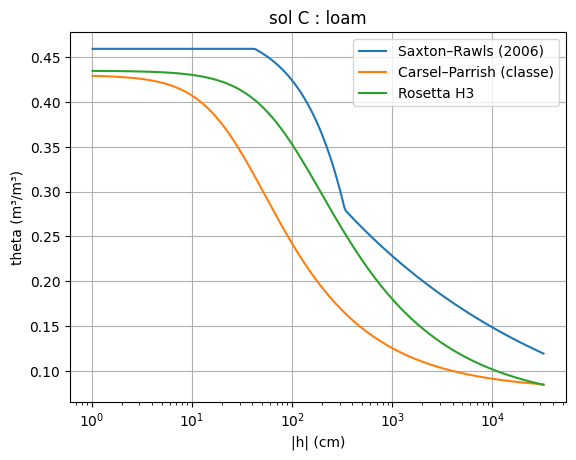

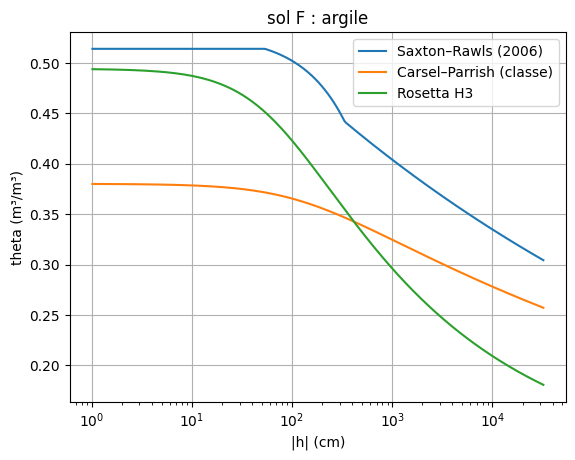

In [14]:
# courbe theta(psi) de Saxton-Rawls (psi > 0 en kPa) : plateau, segment linéaire, puis loi de puissance
def sr_theta(psi, theta_s, theta_33, lam, psi_e):
    B = 1 / lam
    A = np.exp(np.log(33) + B * np.log(theta_33))
    theta = np.zeros(len(psi))
    for k in range(len(psi)):
        if psi[k] >= 33:
            theta[k] = (psi[k] / A) ** (-1 / B)
        elif psi[k] >= psi_e:
            theta[k] = theta_33 + (33 - psi[k]) * (theta_s - theta_33) / (33 - psi_e)
        else:
            theta[k] = theta_s
    return theta

psi = np.logspace(-1, 3.5, 300)    # kPa
h_psi = -psi * KPA                 # cm

for i in [2, 5]:    # sol C (ligne 2) et sol F (ligne 5)
    sol = tex.loc[i, "sol"]
    classe = tex.loc[i, "classe_USDA"]
    theta_SR = sr_theta(psi, tex.loc[i, "theta_s_SR"], tex.loc[i, "theta_33_SR"], tex.loc[i, "lambda_SR"], tex.loc[i, "psi_e_SR"])
    theta_CP = vg_theta(h_psi, cp.loc[classe, "theta_r"], cp.loc[classe, "theta_s"], cp.loc[classe, "alpha"], cp.loc[classe, "n"])
    theta_Ros = vg_theta(h_psi, ros.loc[i, "theta_r"], ros.loc[i, "theta_s"], ros.loc[i, "alpha_1cm"], ros.loc[i, "n"])
    plt.figure()
    plt.semilogx(-h_psi, theta_SR, label="Saxton–Rawls (2006)")
    plt.semilogx(-h_psi, theta_CP, label="Carsel–Parrish (classe)")
    plt.semilogx(-h_psi, theta_Ros, label="Rosetta H3")
    plt.title("sol " + sol + " : " + classe)
    plt.xlabel("|h| (cm)")
    plt.ylabel("theta (m³/m³)")
    plt.legend()
    plt.grid(True)
    plt.show()

**4. Dispersion entre les sources : RU et log10 Ks**

In [15]:
# réserve utile (mm/m) entre 33 et 1500 kPa selon chaque source
tex["RU_SR"] = (tex["theta_33_SR"] - tex["theta_1500_SR"]) * 1000
tex["RU_CP"] = (tex["theta_33_CP"] - tex["theta_1500_CP"]) * 1000
tex["RU_Ros"] = (tex["theta_33_Ros"] - tex["theta_1500_Ros"]) * 1000
ru = tex[["RU_SR", "RU_CP", "RU_Ros"]]

# Ks varie sur plusieurs ordres de grandeur : on compare les log10
log_ks = np.log10(tex[["Ks_SR", "Ks_CP", "Ks_Ros"]])

synth = pd.DataFrame()
synth["sol"] = tex["sol"]
synth["RU_moyenne"] = ru.mean(axis=1)
synth["RU_ecart_type"] = ru.std(axis=1)
synth["CV_RU_pct"] = 100 * synth["RU_ecart_type"] / synth["RU_moyenne"]
synth["log10Ks_moyen"] = log_ks.mean(axis=1)
synth["log10Ks_ecart_type"] = log_ks.std(axis=1)
synth["facteur_sur_Ks"] = 10 ** synth["log10Ks_ecart_type"]
print(synth.round(2))

  sol  RU_moyenne  RU_ecart_type  CV_RU_pct  log10Ks_moyen  \
0   A       14.24          22.86     160.55           2.73   
1   B       74.64          49.24      65.97           1.88   
2   C      125.93          43.93      34.88           1.35   
3   D      185.03          44.68      24.15           1.32   
4   E      136.46          15.22      11.16           0.92   
5   F      116.87          40.04      34.26           0.73   

   log10Ks_ecart_type  facteur_sur_Ks  
0                0.18            1.50  
1                0.26            1.81  
2                0.25            1.77  
3                0.32            2.09  
4                0.13            1.35  
5                0.42            2.62  


**Commentaire (instructeur).** Sur la RU, les trois FPT s'écartent typiquement de 15–50 mm/m (CV de 10 à 65 %, hors sable dont la RU est minuscule) ; sur $K_s$,
l'écart type de $\log_{10}K_s$ vaut 0,15–0,4, soit un facteur 1,5 à 2,6 entre sources « raisonnables » — et bien plus encore par
rapport à des mesures de terrain (Schaap et al., 2001 : erreur d'un facteur 4 à 5). $K_s$ est de loin la grandeur la plus incertaine.
Carsel & Parrish sous-estime systématiquement $\theta_{33}$ des loams par rapport à Saxton–Rawls et Rosetta. Conclusion pratique :
mesurer $K_s$ et $\theta_s$ localement, utiliser les FPT pour $\alpha$ et $n$ en première approche, et propager l'incertitude dans
les simulations.

## Exercice 4 — Hystérésis : courbes principales et courbes de balayage (Kool & Parker, 1987)  *(≈ 10 min)*

Loam sableux : $\theta_r = 0{,}065$, $\theta_s^d = 0{,}41$, $\alpha_d = 0{,}075$ cm$^{-1}$, $n = 1{,}89$ ; humectation : $\alpha_w = 2\alpha_d$,
$\theta_s^w = 0{,}37$ (air piégé). Avec $S_e^d(h) = [1+(\alpha_d|h|)^n]^{-m}$ et $S_e^w(h) = [1+(\alpha_w|h|)^n]^{-m}$ :

* courbe de balayage de **drainage** depuis le point de renversement $(h_\Delta, \theta_\Delta)$ :
  $\theta(h) = \theta_r + (\theta_s' - \theta_r)\,S_e^d(h)$ avec $\theta_s' = \theta_r + (\theta_\Delta - \theta_r)/S_e^d(h_\Delta)$ ;
* courbe de balayage d'**humectation** : $\theta(h) = \theta_r' + (\theta_s^w - \theta_r')\,S_e^w(h)$ avec
  $\theta_r' = [\theta_\Delta - \theta_s^w S_e^w(h_\Delta)]/[1 - S_e^w(h_\Delta)]$.

1. Programmer `theta_d(h)` et `theta_w(h)` (courbes principales) et les tracer.
2. Programmer `balayage_drainage(h, h_delta, theta_delta)` et `balayage_humectation(h, h_delta, theta_delta)`, puis tracer le cycle :
   drainage principal de 0 à $-200$ cm, humectation (balayage) de $-200$ à $-20$ cm, drainage (balayage) de $-20$ à $-500$ cm.
3. Donner $\theta$ à $h = -50$ cm sur les deux courbes principales et sur les deux branches de balayage ; quelle erreur commet-on
   en utilisant la seule courbe de drainage ?

**1. Courbes principales de drainage et d'humectation**

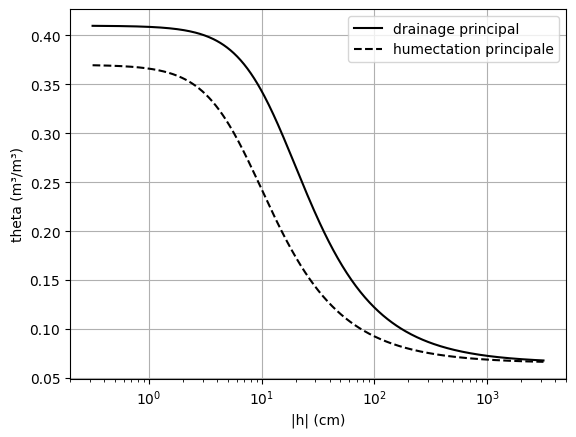

In [16]:
theta_r = 0.065
theta_s_d = 0.41          # saturation en drainage
alpha_d = 0.075           # 1/cm, drainage
n = 1.89
alpha_w = 2 * alpha_d     # humectation : alpha double
theta_s_w = 0.37          # saturation en humectation (air piégé)

# saturation effective de van Genuchten
def vg_Se(h, alpha, n):
    m = 1 - 1 / n
    return (1 + (alpha * np.abs(h)) ** n) ** (-m)

# courbe principale de drainage
def theta_d(h):
    return theta_r + (theta_s_d - theta_r) * vg_Se(h, alpha_d, n)

# courbe principale d'humectation
def theta_w(h):
    return theta_r + (theta_s_w - theta_r) * vg_Se(h, alpha_w, n)

hh = -np.logspace(-0.5, 3.5, 400)
plt.figure()
plt.semilogx(-hh, theta_d(hh), "k-", label="drainage principal")
plt.semilogx(-hh, theta_w(hh), "k--", label="humectation principale")
plt.xlabel("|h| (cm)")
plt.ylabel("theta (m³/m³)")
plt.legend()
plt.grid(True)
plt.show()

**2. Courbes de balayage et cycle drainage – humectation – drainage**

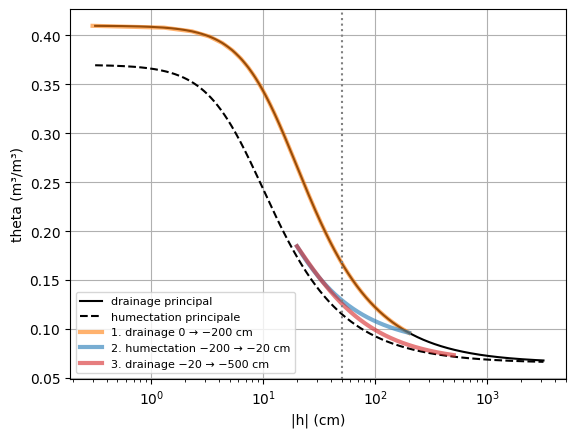

In [17]:
# balayage de drainage passant par (h_delta, theta_delta) : theta_s' ajusté, theta_r inchangé
def balayage_drainage(h, h_delta, theta_delta):
    theta_s_prime = theta_r + (theta_delta - theta_r) / vg_Se(h_delta, alpha_d, n)
    return theta_r + (theta_s_prime - theta_r) * vg_Se(h, alpha_d, n)

# balayage d'humectation passant par (h_delta, theta_delta) : theta_r' ajusté, theta_s^w inchangé
def balayage_humectation(h, h_delta, theta_delta):
    Se_delta = vg_Se(h_delta, alpha_w, n)
    theta_r_prime = (theta_delta - theta_s_w * Se_delta) / (1 - Se_delta)
    return theta_r_prime + (theta_s_w - theta_r_prime) * vg_Se(h, alpha_w, n)

# branche 1 : drainage principal de 0 à -200 cm
h1 = -np.linspace(0.3, 200, 200)
th1 = theta_d(h1)
# branche 2 : humectation de -200 à -20 cm, depuis le dernier point de la branche 1
h2 = -np.linspace(200, 20, 200)
th2 = balayage_humectation(h2, -200, th1[-1])
# branche 3 : drainage de -20 à -500 cm, depuis le dernier point de la branche 2
h3 = -np.linspace(20, 500, 300)
th3 = balayage_drainage(h3, -20, th2[-1])

plt.figure()
plt.semilogx(-hh, theta_d(hh), "k-", label="drainage principal")
plt.semilogx(-hh, theta_w(hh), "k--", label="humectation principale")
plt.semilogx(-h1, th1, "-", color="C1", linewidth=3, alpha=0.6, label="1. drainage 0 → −200 cm")
plt.semilogx(-h2, th2, "-", color="C0", linewidth=3, alpha=0.6, label="2. humectation −200 → −20 cm")
plt.semilogx(-h3, th3, "-", color="C3", linewidth=3, alpha=0.6, label="3. drainage −20 → −500 cm")
plt.axvline(50, color="gray", linestyle=":")
plt.xlabel("|h| (cm)")
plt.ylabel("theta (m³/m³)")
plt.legend(fontsize=8)
plt.grid(True)
plt.show()

**3. Teneur en eau à h = −50 cm sur les quatre courbes**

In [18]:
t_d = theta_d(-50)
t_w = theta_w(-50)
t_b2 = balayage_humectation(-50, -200, th1[-1])
t_b3 = balayage_drainage(-50, -20, th2[-1])
print("theta(h = -50 cm) sur le drainage principal        =", round(t_d, 3))
print("theta(h = -50 cm) sur l'humectation principale     =", round(t_w, 3))
print("theta(h = -50 cm) sur le balayage d'humectation (2) =", round(t_b2, 3))
print("theta(h = -50 cm) sur le balayage de drainage (3)   =", round(t_b3, 3))

ecart_max = max(t_d, t_w, t_b2, t_b3) - min(t_d, t_w, t_b2, t_b3)
print("Écart max entre branches :", round(ecart_max, 3), "m³/m³, soit", round(100 * ecart_max / t_d), "% de theta sur la courbe de drainage")

theta(h = -50 cm) sur le drainage principal        = 0.168
theta(h = -50 cm) sur l'humectation principale     = 0.115
theta(h = -50 cm) sur le balayage d'humectation (2) = 0.129
theta(h = -50 cm) sur le balayage de drainage (3)   = 0.126
Écart max entre branches : 0.052 m³/m³, soit 31 % de theta sur la courbe de drainage


**Commentaire (instructeur).** À $h = -50$ cm, $\theta$ vaut 0,17 sur la courbe de drainage principale mais seulement 0,12 sur la courbe d'humectation
principale ; les branches de balayage se placent entre les deux (0,13). Ignorer l'hystérésis (n'utiliser que la courbe de drainage,
comme la plupart des modèles) surestime $\theta$ de ~0,05 (30 %) en phase d'humectation : effet majeur pour un sol sableux, faible
pour une argile. Remarquer que la branche 3 (drainage depuis −20 cm) reste sous la courbe de drainage principale.

## Exercice 5 — Bonus — modèle de Kosugi  *(≈ facultatif)*

Sur l'argile de l'exercice 1, ajuster le modèle de Kosugi (1996), $\theta = \theta_r + (\theta_s - \theta_r)\,S_e$ avec
$S_e = \tfrac12\,\mathrm{erfc}[\ln(|h|/h_m)/(\sqrt2\sigma)]$ (distribution log-normale des rayons de pores : $h_m$ = pression
médiane en cm, $\sigma$ = étalement), avec les bornes $1 \le h_m \le 10^5$ cm et $0{,}2 \le \sigma \le 6$.
Comparer son RMSE à celui du modèle VG et superposer les deux courbes aux mesures.

**Ajustement de Kosugi sur l'argile**

Kosugi : theta_r = 0.177, theta_s = 0.385, hm = 8721 cm, sigma = 3.48, RMSE = 0.0068
VG (exercice 1) : RMSE = 0.0074


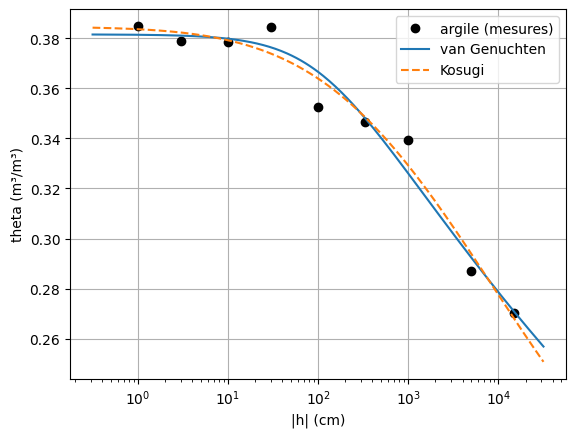

In [19]:
# modèle de Kosugi (1996) ; erfc = fonction d'erreur complémentaire
def kosugi_theta(h, thr, ths, hm, sigma):
    Se = 0.5 * erfc(np.log(np.abs(h) / hm) / (np.sqrt(2) * sigma))
    return thr + (ths - thr) * Se

g = mes[mes["sol"] == "argile"]
h = g["h_cm"].to_numpy()
theta = g["theta"].to_numpy()
popt, pcov = curve_fit(kosugi_theta, h, theta, p0=[0.05, 0.4, 500, 2.0], bounds=([0, 0.3, 1, 0.2], [0.25, 0.6, 1e5, 6]))
thr_k = popt[0]
ths_k = popt[1]
hm_k = popt[2]
sigma_k = popt[3]
erreur = theta - kosugi_theta(h, thr_k, ths_k, hm_k, sigma_k)
rmse_k = np.sqrt(np.mean(erreur**2))
print(f"Kosugi : theta_r = {thr_k:.3f}, theta_s = {ths_k:.3f}, hm = {hm_k:.0f} cm, sigma = {sigma_k:.2f}, RMSE = {rmse_k:.4f}")
print("VG (exercice 1) : RMSE =", round(par_vg.loc["argile", "RMSE"], 4))

hh = -np.logspace(-0.5, 4.5, 300)
theta_vg = vg_theta(hh, par_vg.loc["argile", "theta_r"], par_vg.loc["argile", "theta_s"], par_vg.loc["argile", "alpha"], par_vg.loc["argile", "n"])
plt.figure()
plt.semilogx(-h, theta, "ko", label="argile (mesures)")
plt.semilogx(-hh, theta_vg, "-", label="van Genuchten")
plt.semilogx(-hh, kosugi_theta(hh, thr_k, ths_k, hm_k, sigma_k), "--", label="Kosugi")
plt.xlabel("|h| (cm)")
plt.ylabel("theta (m³/m³)")
plt.legend()
plt.grid(True)
plt.show()

**Commentaire (instructeur).** Kosugi et VG sont équivalents sur ces 9 points (RMSE 0,007 contre 0,007, de l'ordre du bruit de 0,008) ; Kosugi a l'avantage de
paramètres à sens physique direct ($h_m$ = pression médiane des pores, $\sigma$ = étalement de la distribution). Avec 9 points,
seuls des modèles à 4 paramètres sont identifiables : un modèle bimodal à 7 paramètres (Durner) descendrait sous le bruit
(surajustement), ce que le critère AICc rejette.

## Pour aller plus loin

* Exercice 1 : refaire l'ajustement en fixant $\theta_s$ à la valeur mesurée et $\theta_r = 0$ ; comparer les incertitudes sur $\alpha$ et $n$.
* Exercice 3 : ajouter la FPT HYPRES (Wösten et al., 1999) et comparer.
* Exercice 4 : implémenter la correction de Lenhard et al. (1991) contre le « pompage » sur plusieurs cycles successifs.
* Bonus : ajuster le modèle bimodal de Durner (1994) à 7 paramètres et comparer VG, Kosugi et Durner avec le critère
  $\mathrm{AIC}_c = N\ln(\Phi/N) + 2k + 2k(k+1)/(N-k-1)$.